# Exp7.3.8 — LIF current-gain sweep

Analysis-only notebook. Training and gain selection are performed by the Slurm array jobs; this notebook reads finalized artifacts only.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
artifact = root / 'notebooks/artifacts/experiment_7_3_8_lif_gain_sweep/lif_gain_sweep_v1'
method_summary = pd.read_csv(artifact / 'method_summary.csv')
gain_summary = pd.read_csv(artifact / 'gain_sweep_summary.csv')
contrast_summary = pd.read_csv(artifact / 'contrast_summary.csv')
bias_summary = pd.read_csv(artifact / 'count_bias_summary.csv')


## Method-level comparison
Only aggregated methods are shown here; per-seed rows remain in the finalized CSV artifacts.

In [2]:
display(method_summary[['method', 'test_ba_mean', 'test_ba_std', 'selected_gain_mean']])
display(contrast_summary)


,method,test_ba_mean,test_ba_std,selected_gain_mean
0,A0_linear_no_bias_W0,0.540981,0.036907,NaN
1,A1_linear_affine_W1_b1,0.586273,0.009744,NaN
2,A2_linear_hybrid_W0_b1,0.479460,0.093157,NaN
3,A3_linear_affine_W1_bias_off,0.415948,0.032329,NaN
4,B0_affineW_lif_selected_gain,0.420033,0.021735,13.333333
5,B1_affineW_lif_continuous_count_bias,0.506952,0.010554,13.333333
6,B2_affineW_lif_integer_count_bias,0.507105,0.015073,13.333333
7,C0_noBiasW_lif_selected_gain,0.515630,0.007577,6.666667
8,C1_noBiasW_lif_continuous_count_bias,0.520235,0.027800,6.666667
9,C2_noBiasW_lif_integer_count_bias,0.520975,0.021715,6.666667


,contrast,mean,std,count
0,affine_vs_no_bias_linear_pp,4.529198,3.331324,3.0
1,hybrid_b1_effect_on_W0_pp,-6.152181,12.644490,3.0
2,same_W1_bias_effect_pp,17.032574,4.190150,3.0
3,affineW_gain_lif_gap_to_affine_linear_pp,16.624047,3.147919,3.0
4,affineW_count_bias_recovery_pp,8.691910,2.647741,3.0
5,noBiasW_gain_lif_gap_to_no_bias_linear_pp,2.535173,2.938481,3.0
6,noBiasW_count_bias_recovery_pp,0.460558,2.973093,3.0
7,selected_gain_affineW,13.333333,4.618802,3.0
8,selected_gain_noBiasW,6.666667,8.082904,3.0


## Gain-response curves
Validation selects the gain; test curves are plotted only for post-hoc interpretation.

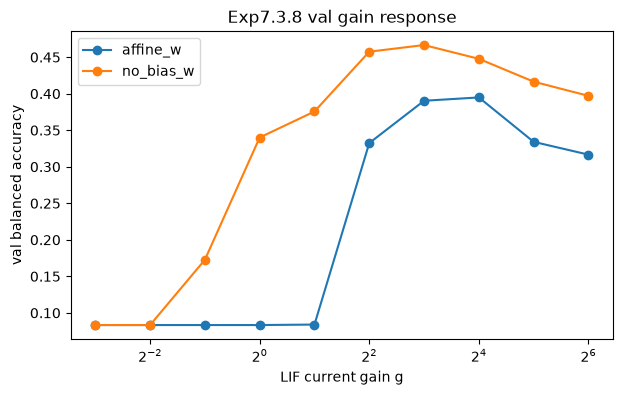

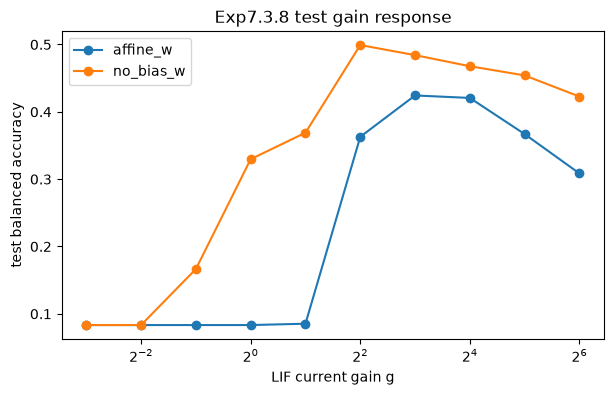

In [3]:
for split in ['val', 'test']:
    fig, ax = plt.subplots(figsize=(7, 4))
    view = gain_summary[gain_summary['split'] == split]
    for source, group in view.groupby('weight_source'):
        group = group.sort_values('gain')
        ax.plot(group['gain'], group['balanced_accuracy_mean'], marker='o', label=source)
    ax.set_xscale('log', base=2)
    ax.set_xlabel('LIF current gain g')
    ax.set_ylabel(f'{split} balanced accuracy')
    ax.set_title(f'Exp7.3.8 {split} gain response')
    ax.legend()
    plt.show()


## Operating-regime diagnostics

In [4]:
cols = ['weight_source', 'gain', 'split', 'zero_output_fraction_mean', 'mean_total_output_spikes_mean', 'mean_active_output_classes_mean', 'mean_per_class_count_variance_mean']
display(gain_summary[gain_summary['split'] == 'val'][cols].sort_values(['weight_source', 'gain']))


,weight_source,gain,split,zero_output_fraction_mean,mean_total_output_spikes_mean,mean_active_output_classes_mean,mean_per_class_count_variance_mean
2,affine_w,0.125,val,1.000000,0.000000,0.000000,0.000000
5,affine_w,0.250,val,1.000000,0.000000,0.000000,0.000000
8,affine_w,0.500,val,1.000000,0.000000,0.000000,0.000000
11,affine_w,1.000,val,1.000000,0.000000,0.000000,0.000000
14,affine_w,2.000,val,0.989418,0.010582,0.010582,0.000864
17,affine_w,4.000,val,0.145503,15.648148,2.716931,12.178654
20,affine_w,8.000,val,0.021164,99.912698,6.574074,139.979846
23,affine_w,16.000,val,0.005291,220.653439,9.029101,332.232278
26,affine_w,32.000,val,0.002646,314.124339,10.113757,445.515966
29,affine_w,64.000,val,0.000000,373.116402,10.679894,506.010316


## Learned count-space offsets after gain selection

In [5]:
display(bias_summary)


,weight_source,class_index,q_centered_mean,q_centered_std,q_centered_count,q_nonnegative_mean,q_nonnegative_std,q_nonnegative_count,q_integer_mean,q_integer_std,q_integer_count
0,affine_w,0,-9.947928,0.436636,3,0.181739,0.185697,3,0.000000,0.000000,3
1,affine_w,1,-9.617384,0.899137,3,0.512283,0.822209,3,0.333333,0.577350,3
2,affine_w,2,8.893747,1.513510,3,19.023413,1.640488,3,19.000000,2.000000,3
3,affine_w,3,0.424302,1.720288,3,10.553969,1.391671,3,10.333333,1.527525,3
4,affine_w,4,-8.741727,2.123631,3,1.387940,2.403982,3,1.333333,2.309401,3
5,affine_w,5,0.057190,1.821063,3,10.186856,1.943853,3,10.000000,2.000000,3
6,affine_w,6,-9.074396,0.592889,3,1.055270,0.604907,3,1.333333,0.577350,3
7,affine_w,7,11.940047,0.887568,3,22.069713,1.105055,3,22.000000,1.000000,3
8,affine_w,8,11.918180,1.369247,3,22.047847,1.322570,3,22.333333,1.154701,3
9,affine_w,9,-4.466758,1.298920,3,5.662909,0.979151,3,5.666667,1.154701,3
